# Variational inference

{class}`liesel.optim.LieselVI` fits an approximate posterior by minimizing the
negative evidence lower bound (ELBO). Fit a variational distribution, then sample
it to summarize the target model's parameters.

## Fit a Gaussian family

This example estimates a Normal mean with known observation scale. All parameters
are on the real line. Transform constrained parameters before constructing the
variational family, and transform draws back when summarizing them.

In [1]:
import jax
import jax.numpy as jnp
import optax
import pandas as pd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

loc = lsl.Var.new_param(0.0, dist=lsl.Dist(tfd.Normal, 0.0, 1.0), name="loc")

y = lsl.Var.new_obs(
    jnp.array([0.9, 1.4, 0.8, 1.2, 0.7, 1.0]),
    dist=lsl.Dist(tfd.Normal, loc, 1.0),
    name="y",
)
model = lsl.Model(y)

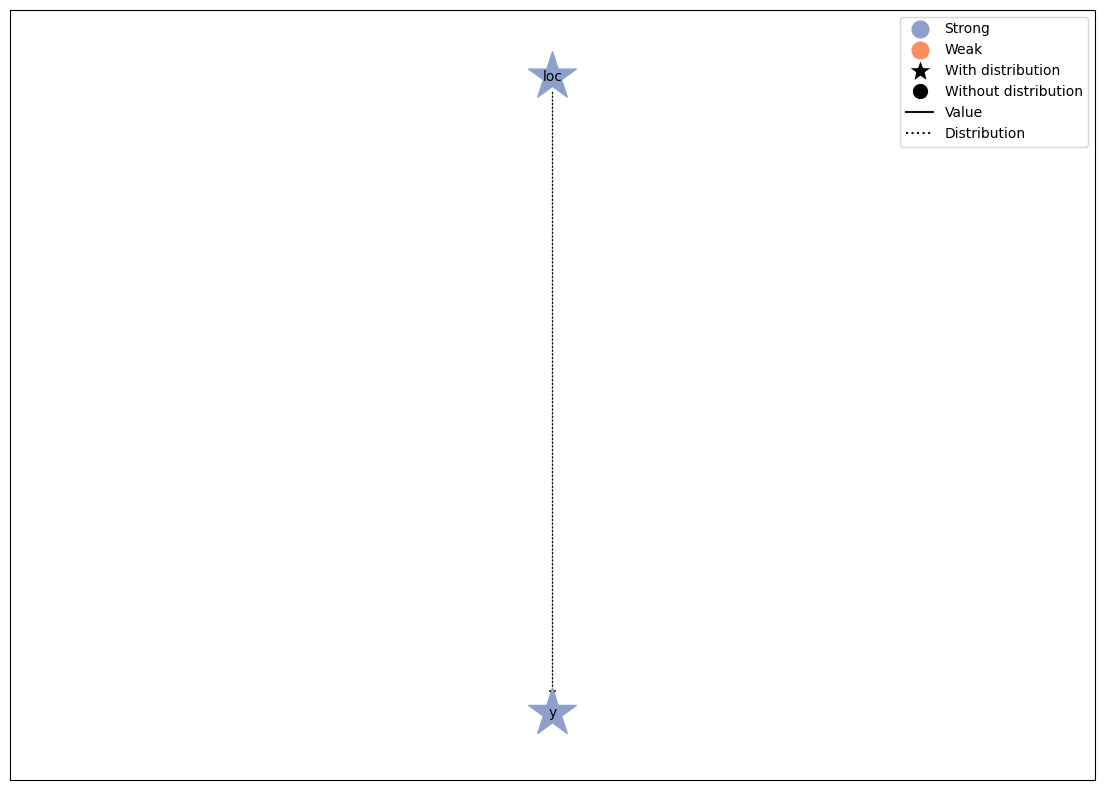

In [2]:
model.plot()

{class}`~liesel.optim.VDist` selects `loc` and builds its Gaussian family;
{meth}`NegElboLoss.from_vdist <liesel.optim.NegElboLoss.from_vdist>` connects it to the target model. We choose initial SD
`0.5`, 16 Monte Carlo draws per step, and a 300-epoch budget. The default objective
includes target priors; extra {ref}`q-parameter penalties <vi-q-prior-penalties>`
are opt-in.

In [3]:
vdist = opt.VDist(["loc"], model).mvn_diag(scale_diag=0.5).build()
loss = opt.NegElboLoss.from_vdist(vdist, nsamples=16, scale=True)

result = opt.LieselVI(
    model,
    loss=loss,
    optimizers=optax.adam(0.01),
    loss_monitor=opt.EmaTrainLossMonitor(effective_window=20.0),
    stopper=opt.Stopper(epochs=300, patience=300),
    seed=42,
    show_progress=False,
).fit()

liesel.optim.engine - INFO - Initializing optimization at epoch 0


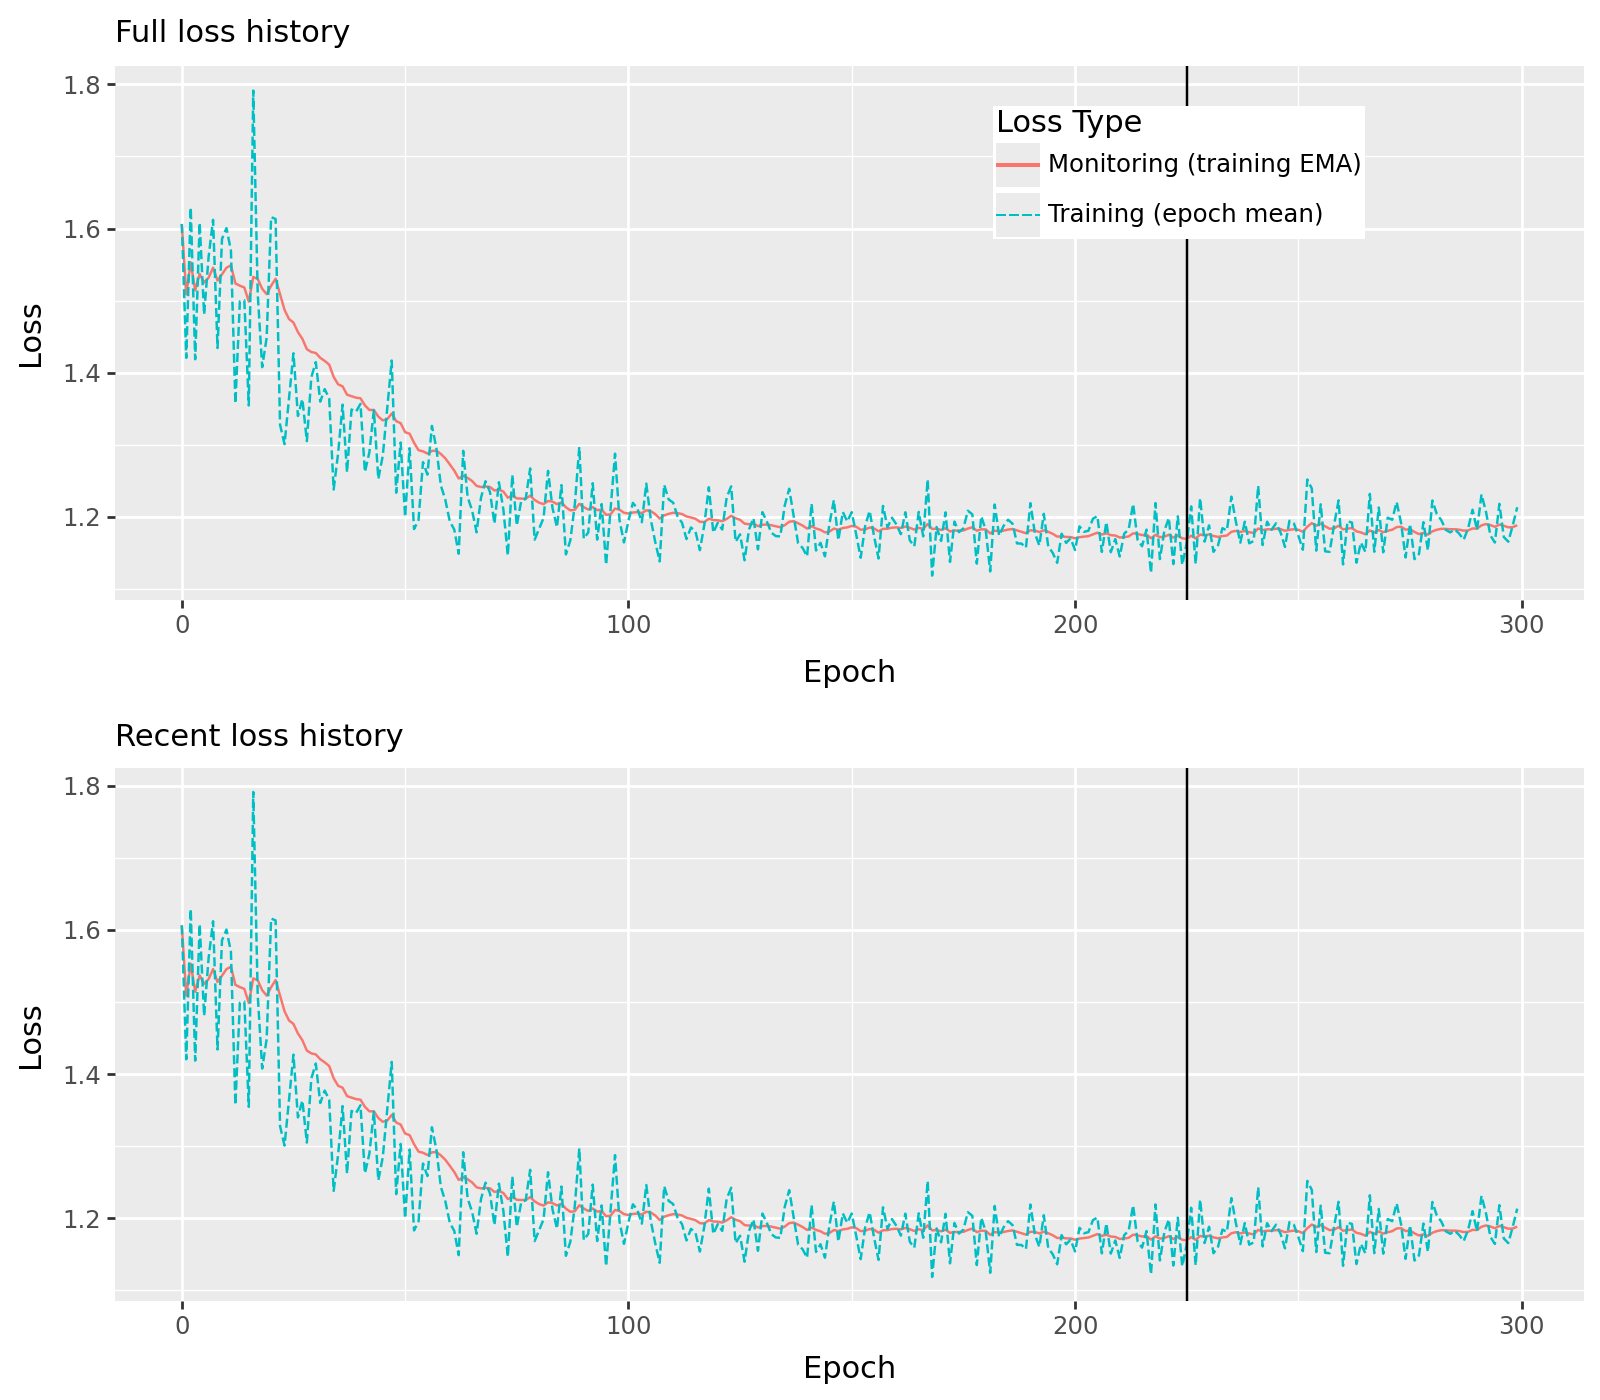

In [4]:
result.plot_loss_overview()

Fitting leaves the supplied model unchanged. Inspect loss and parameter paths
and posterior predictions: a decreasing loss alone does not establish accuracy.
See {doc}`variational-models` for Gaussian shortcuts and independent blocks.

## Sample the fitted family

In [5]:
posterior = loss.approximate_joint_posterior(result)
samples = posterior.sample(2_000, seed=jax.random.key(43))

In [6]:
pd.DataFrame(
    {"Mean": [samples["loc"].mean()], "SD": [samples["loc"].std()]},
    index=["loc"],
).astype(float).round(3)

,Mean,SD
loc,0.849,0.374


The exact posterior mean in this example is 6/7 and its standard deviation is
1/sqrt(7). Monte Carlo summaries fluctuate around the fitted family's values.

{meth}`approximate_joint_posterior <liesel.optim.NegElboLoss.approximate_joint_posterior>` binds the final iterate by default. Selecting the
minimum noisy monitoring loss can favor a lucky estimate; use `at="min_monitor"`
only when you intend that selection. Use a result from the same loss and keep its
variational graph and draw mapping unchanged; see
{class}`~liesel.optim.VariationalApproximation` for the full contract.

{meth}`sample(seed=key) <liesel.optim.VariationalApproximation.sample>` returns one draw in the target's original parameter shapes.
An integer or tuple adds leading sample axes, also accepted by {meth}`model.predict <liesel.model.Model.predict>`:

In [7]:
samples = posterior.sample((1, 1_000), seed=jax.random.key(44))
predicted = model.predict(samples)

In [8]:
samples["loc"].shape

(1, 1000)

(vi-initial-scale)=

## Choose an initial scale

Gaussian builders default to SD `0.1` in each parameter's units, including
transformed units such as log standard deviations. Dense blocks start with
Cholesky factor `0.1 * I`; locations use current target values.

This is an initialization heuristic, not a posterior uncertainty estimate or a
scale-invariant recommendation. Narrow starts keep draws local but may expand
slowly; wider starts can increase gradient noise or reach unstable regions.
Choose `scale_diag` or `scale_tril` for your parameter units. Arrays allow different
initial scales across parameters. Check fitted uncertainty and loss paths, and
adjust the learning rate or iteration budget if needed.

(vi-monitoring)=

## Choose a monitor

Both `optimizers` and `loss_monitor` are required. Here,
{class}`~liesel.optim.EmaTrainLossMonitor` uses a span of 20 epoch equivalents:
stronger smoothing reduces noise but responds more slowly to changes. The span
is neither a hard window nor a half-life. `"train_full_data"` instead evaluates
all training rows after each epoch; its variational draws still make it noisy.

Without an explicit stopper, {class}`LieselVI <liesel.optim.LieselVI>` runs 1,000 epochs without early stopping.
A smaller `patience` enables early stopping, which stochastic fluctuations can
trigger prematurely. See {doc}`optimizer-monitoring` for stopping and histories.
ELBO losses do not support validation splits; use held-out test data for a final
predictive check, as in the basic tutorial.

## Work through examples

```{toctree}
:maxdepth: 1

Overview <self>
variational-models
Laplace initialization <variational-laplace>
Fit a Gaussian family <tutorials/notebooks/11-liesel-vi-basic>
Fit two data groups <tutorials/notebooks/12-liesel-vi-advanced>
```

## Configure the fit

For multiple observation sizes, pass an explicit split after checking row
alignment; see {doc}`optimizer-splitting` and the two-group tutorial above.

* {doc}`optimizer-batching`: minibatches and fixed computed data.
* {doc}`optimizer-loss-scaling`: sample counts and normalization.
* {doc}`optimizer-weighted-batching`: unequal sampling probabilities.
* {doc}`optimizer-customization`: learning rates and optimizer blocks. VI blocks
  select names in `loss.q.parameters`.
* {doc}`optimizer-checkpointing`: resuming a fit.

See {class}`~liesel.optim.LieselVI` and {class}`~liesel.optim.NegElboLoss` for
arguments. Configure an explicit loss on the loss itself; wrapper options do not
override its sample count, scaling, entropy, or prior settings.